
### **Sign Language Recognition - Deep Learning**


Libraries:

In [37]:


import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

Implementation:

In [38]:
def segmentation(frame, threshold=40):

    global background

    diff = cv2.absdiff(background.astype("uint8"), frame)

    _, processed_frame = cv2.threshold(
        diff,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    
    contours, _ = cv2.findContours(processed_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None
    else :
        contours = max(contours, key=cv2.contourArea)

    return (processed_frame, contours)

### Generate Dataset

In [39]:
# Camera Initialization
cam = cv2.VideoCapture(0, cv2.CAP_V4L2)


# ROI (Region of Interest)
TOP = 50
BOTTOM = 300
RIGHT = 50
LEFT = 250

# Global Variables
background = None
count = 0
digit = 0
sample_num = 0


while True:

    value, frame = cam.read()

    
    frame_copy = frame.copy()
    frame_copy = cv2.flip(frame_copy, 1) # (mirror effect)

    
    roi = frame_copy[TOP:BOTTOM, RIGHT:LEFT]

    # Preprocessing
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_gray = cv2.GaussianBlur(roi_gray, (7, 7), 0)


    if background is None:
        background = roi_gray.copy().astype("float")

    # Draw ROI rectangle
    cv2.rectangle(frame_copy, (RIGHT, TOP), (LEFT, BOTTOM), (0, 255, 0), 2)

    

    # Background learning (first 30 frames)
    if count < 30:
        cv2.accumulateWeighted(roi_gray, background, 0.5)
        cv2.putText(frame_copy, "Loading ...", (280, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)


    
    collection = segmentation(roi_gray)

    if collection is not None:
        roi_processed, contours = collection 
        cv2.drawContours(
                        frame_copy,
                        [contours+(RIGHT, TOP)], # this is for alignment of contours with original frame
                        -1, # draw all contours
                        (0,0,255), 
                        2 
                                    ) 
        cv2.imshow("Processed", roi_processed)
        if k == ord(" "):
            cv2.putText(frame_copy, str(sample_num)+ "Gesture ("+ str(digit)+")", (70, 45), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.imwrite("gesture/train/" + str(digit) + "/" + str(digit) +"-" + str(sample_num) + ".jpg", roi_processed)
            sample_num += 1

    # Show camera
    cv2.putText(frame_copy, "Gesture ("+ str(digit)+")", (60, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imshow("Camera", frame_copy)
    count += 1

    # Exit with ESC
    k = cv2.waitKey(1)
    if k == 27:
        break
    
    elif k == 13: # press (Enter) key to switch to next gesture
        
        digit = (digit + 1) % 11 
        sample_num = 0
        
        


cam.release()
cv2.destroyAllWindows()

In [75]:
train_data_path = "gesture/train"
test_data_path = "gesture/test"

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.2,
    shear_range=0.1,

    brightness_range=[0.7,1.3],

    fill_mode='nearest'
)

train_data_batches = train_datagen.flow_from_directory(
    train_data_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)


test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

test_data_batches = test_datagen.flow_from_directory(
    test_data_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical'
)
images_train, labels_train = next(train_data_batches)
print("Train Batch shape:", images_train.shape)
print("Train Labels shape:", labels_train.shape)

images_test, labels_test = next(test_data_batches)
print("Test Batch shape:", images_test.shape)
print("Test Labels shape:", labels_test.shape)

Found 11011 images belonging to 11 classes.
Found 462 images belonging to 11 classes.
Train Batch shape: (32, 64, 64, 3)
Train Labels shape: (32, 11)
Test Batch shape: (32, 64, 64, 3)
Test Labels shape: (32, 11)


In [76]:
def display(images):
    fig, axex = plt.subplots(1, 10, figsize=(30, 20))
    for image, ax in zip(images, axex):
        image = np.clip(image, 0, 1)
        ax.imshow(image)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [77]:
print(train_data_batches.class_indices)

{'00': 0, '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6, '07': 7, '08': 8, '09': 9, '10': 10}


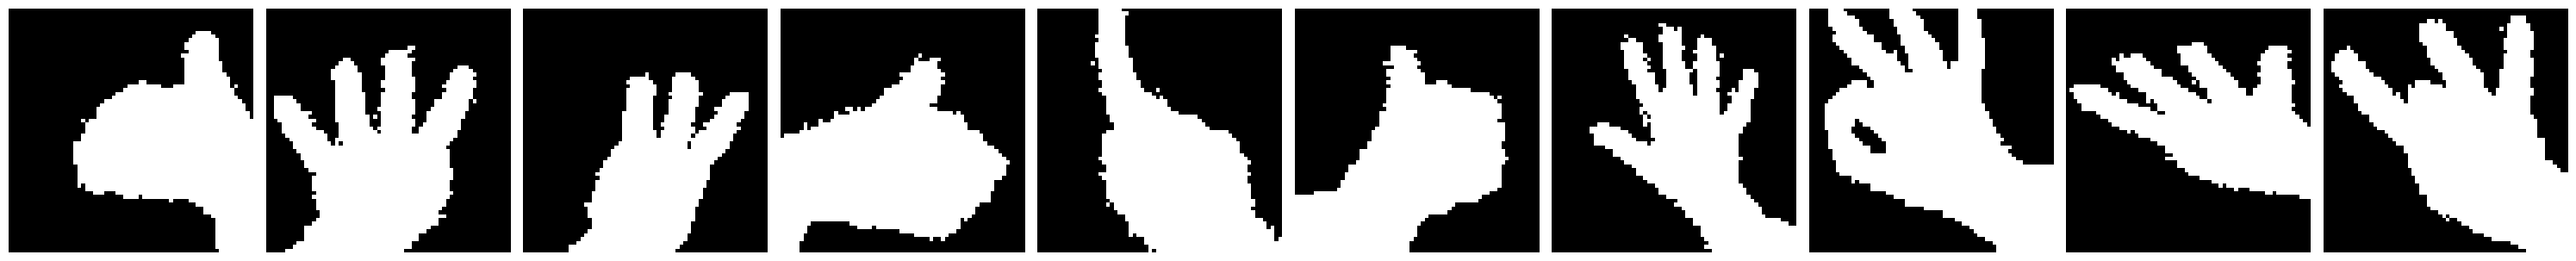

ten
four
six
ten
one
ten
five
nine
four
eight
nine
three
zero
eight
three
three
five
one
four
zero
three
four
two
zero
two
eight
four
three
six
seven
four
one


In [78]:
words = {0: "zero", 1: "one", 2: "two", 3: "three", 4: "four", 5: "five", 6: "six", 7: "seven", 8: "eight", 9: "nine", 10: "ten"}



display(images_train)


def digits(labels):
    for label in labels:
        print(words[np.argmax(label)])
    
digits(labels_train)

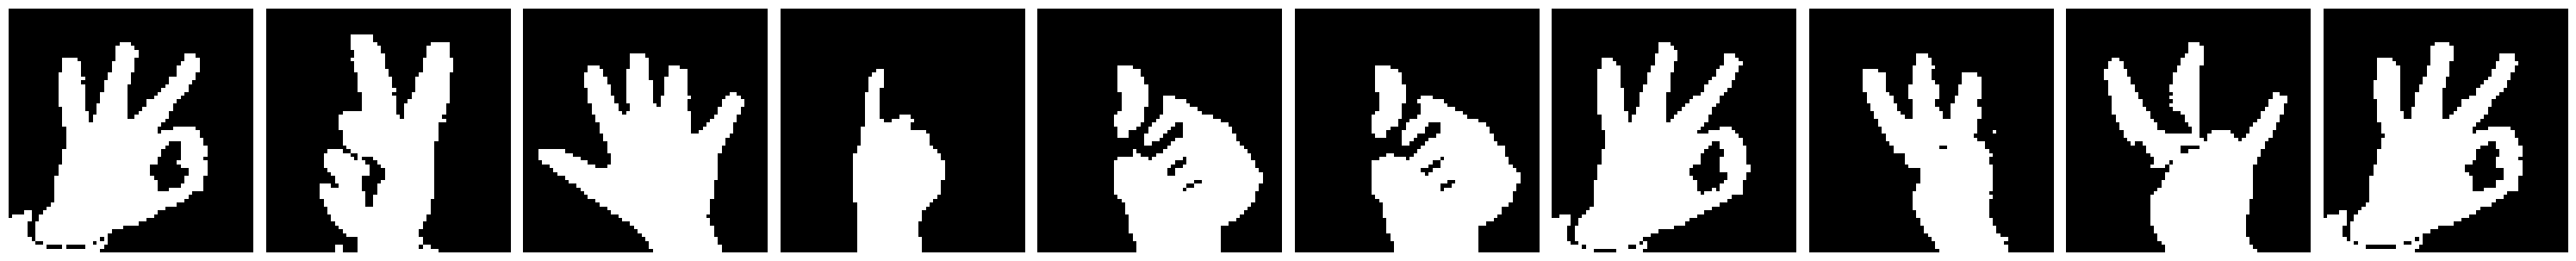

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.

In [79]:
display(images_test)
labels_test

### Create Cnn Model:

In [93]:
# CNN: Convolutional Neural Network

def createModel():
    model = Sequential()
    
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(128, (3, 3), activation='relu', padding='valid')) 
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Flatten())
    
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu')) 
    model.add(Dropout(0.2))
    
    model.add(Dense(128, activation='relu'))
    
    model.add(Dense(11, activation='softmax'))
    
    return model
 
model = createModel()
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,475 (1.58 MB)

 Trainable params: 414,475 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

### Training Cnn Model:

In [94]:

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr= 0.0005)
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, mode='auto', verbose=1)

In [95]:
model.fit(train_data_batches, epochs=15, callbacks=[reduce, early_stop], validation_data=test_data_batches)

Epoch 1/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.4013 - loss: 1.9665 - val_accuracy: 0.1450 - val_loss: 3.0623 - learning_rate: 1.0000e-04
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.7420 - loss: 0.7099 - val_accuracy: 0.1710 - val_loss: 5.8812 - learning_rate: 1.0000e-04
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.8630 - loss: 0.3789 - val_accuracy: 0.1147 - val_loss: 6.2085 - learning_rate: 1.0000e-04
Epoch 4/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 0.9193 - loss: 0.2347 - val_accuracy: 0.1104 - val_loss: 7.7045 - learning_rate: 1.0000e-04
Epoch 4: early stopping


### Testing

In [96]:
score = model.evaluate(images_test, labels_test, verbose=0)
score

[8.39720344543457, 0.0625]

In [97]:
model.metrics_names

['loss', 'compile_metrics']

In [98]:
print(f"{model.metrics_names[0]}: {score[0]}, {model.metrics_names[1]}: {score[1]*100}")

loss: 8.39720344543457, compile_metrics: 6.25


### Model Save:

In [99]:
model.save("sign_language_model.h5")

### usning the model in prediction:

In [100]:
new_model = tf.keras.models.load_model("sign_language_model.h5")
new_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,477 (1.58 MB)

 Trainable params: 414,475 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [108]:
cam = cv2.VideoCapture(0, cv2.CAP_V4L2)



TOP = 50
BOTTOM = 300
RIGHT = 50
LEFT = 250



background = None
count = 0
digit = 0
sample_num = 0
new_model = tf.keras.models.load_model("sign_language_model.h5")




while True:

    value, frame = cam.read()

    
    frame_copy = frame.copy()
    frame_copy = cv2.flip(frame_copy, 1)

    
    roi = frame_copy[TOP:BOTTOM, RIGHT:LEFT]

    
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_gray = cv2.GaussianBlur(roi_gray, (7, 7), 0)

    
    if background is None:
        background = roi_gray.copy().astype("float")

    
    cv2.rectangle(frame_copy, (RIGHT, TOP), (LEFT, BOTTOM), (0, 255, 0), 2)

    

    
    if count < 30:
        cv2.accumulateWeighted(roi_gray, background, 0.5)
        cv2.putText(frame_copy, "Loading ...", (280, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)



    collection = segmentation(roi_gray)

    if collection is not None:
        roi_processed, contours = collection 
        cv2.drawContours(
                        frame_copy,
                        [contours+(RIGHT, TOP)], 
                        -1,
                        (0,0,255), 
                        2 
                                    ) 
        
        
        roi_processed = cv2.resize(roi_processed, (64, 64))
        roi_processed = cv2.cvtColor(roi_processed, cv2.COLOR_GRAY2RGB)
        frame = np.reshape(roi_processed, (1, roi_processed.shape[0], roi_processed.shape[1], 3))
        value = new_model.predict(frame)
        label = words[np.argmax(value)]
        cv2.putText(frame_copy, str(label), (370, 145), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 0), 5)
        cv2.imshow("Processed", roi_processed)
        
        
        
        
    # Show camera
    # cv2.putText(frame_copy, "Gesture ("+ str(digit)+")", (60, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imshow("Camera", frame_copy)
    count += 1

    # Exit with ESC
    k = cv2.waitKey(1)
    if k == 27:
        break
    
    elif k == 13: 
        
        digit = (digit + 1) % 11 
        sample_num = 0
        
        



cam.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━